In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt

In [2]:
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 50

In [3]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "Tomato_Cases",
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

class_names = dataset.class_names  # store before splitting
n_classes = len(class_names)

Found 16011 files belonging to 10 classes.


In [4]:
class_names = dataset.class_names
class_names

['Tomato_Bacterial_spot',
 'Tomato_Early_blight',
 'Tomato_Late_blight',
 'Tomato_Leaf_Mold',
 'Tomato_Septoria_leaf_spot',
 'Tomato_Spider_mites_Two_spotted_spider_mite',
 'Tomato__Target_Spot',
 'Tomato__Tomato_YellowLeaf__Curl_Virus',
 'Tomato__Tomato_mosaic_virus',
 'Tomato_healthy']

In [5]:
len(dataset)

501

In [6]:
# this will take 1 batch, i.e, 32 images
for image_batch, label_batch in dataset.take(1):
    print(image_batch.shape)
    print(label_batch.numpy())

(32, 256, 256, 3)
[1 9 2 7 9 7 7 7 0 5 1 6 3 2 0 0 5 6 2 0 7 4 4 3 7 9 7 0 3 4 9 7]


In [7]:
for image_batch, label_batch in dataset.take(1):
    print(image_batch[0].numpy)

<bound method _EagerTensorBase.numpy of <tf.Tensor: shape=(256, 256, 3), dtype=float32, numpy=
array([[[154., 152., 157.],
        [153., 151., 156.],
        [153., 151., 156.],
        ...,
        [113., 109., 110.],
        [127., 123., 124.],
        [ 97.,  93.,  94.]],

       [[152., 150., 155.],
        [153., 151., 156.],
        [154., 152., 157.],
        ...,
        [ 96.,  92.,  93.],
        [128., 124., 125.],
        [124., 120., 121.]],

       [[153., 151., 156.],
        [154., 152., 157.],
        [156., 154., 159.],
        ...,
        [131., 127., 128.],
        [145., 141., 142.],
        [129., 125., 126.]],

       ...,

       [[159., 158., 164.],
        [160., 159., 165.],
        [160., 159., 165.],
        ...,
        [134., 132., 137.],
        [149., 147., 152.],
        [116., 114., 119.]],

       [[154., 153., 159.],
        [156., 155., 161.],
        [159., 158., 164.],
        ...,
        [142., 140., 145.],
        [127., 125., 130.],
       

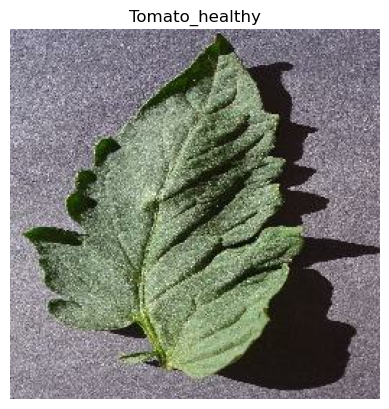

In [8]:
for image_batch, label_batch in dataset.take(1):
    plt.imshow(image_batch[0].numpy().astype("uint8"))
    # displaying label
    plt.title(class_names[label_batch[0]])
    # turning off the axis
    plt.axis("off")

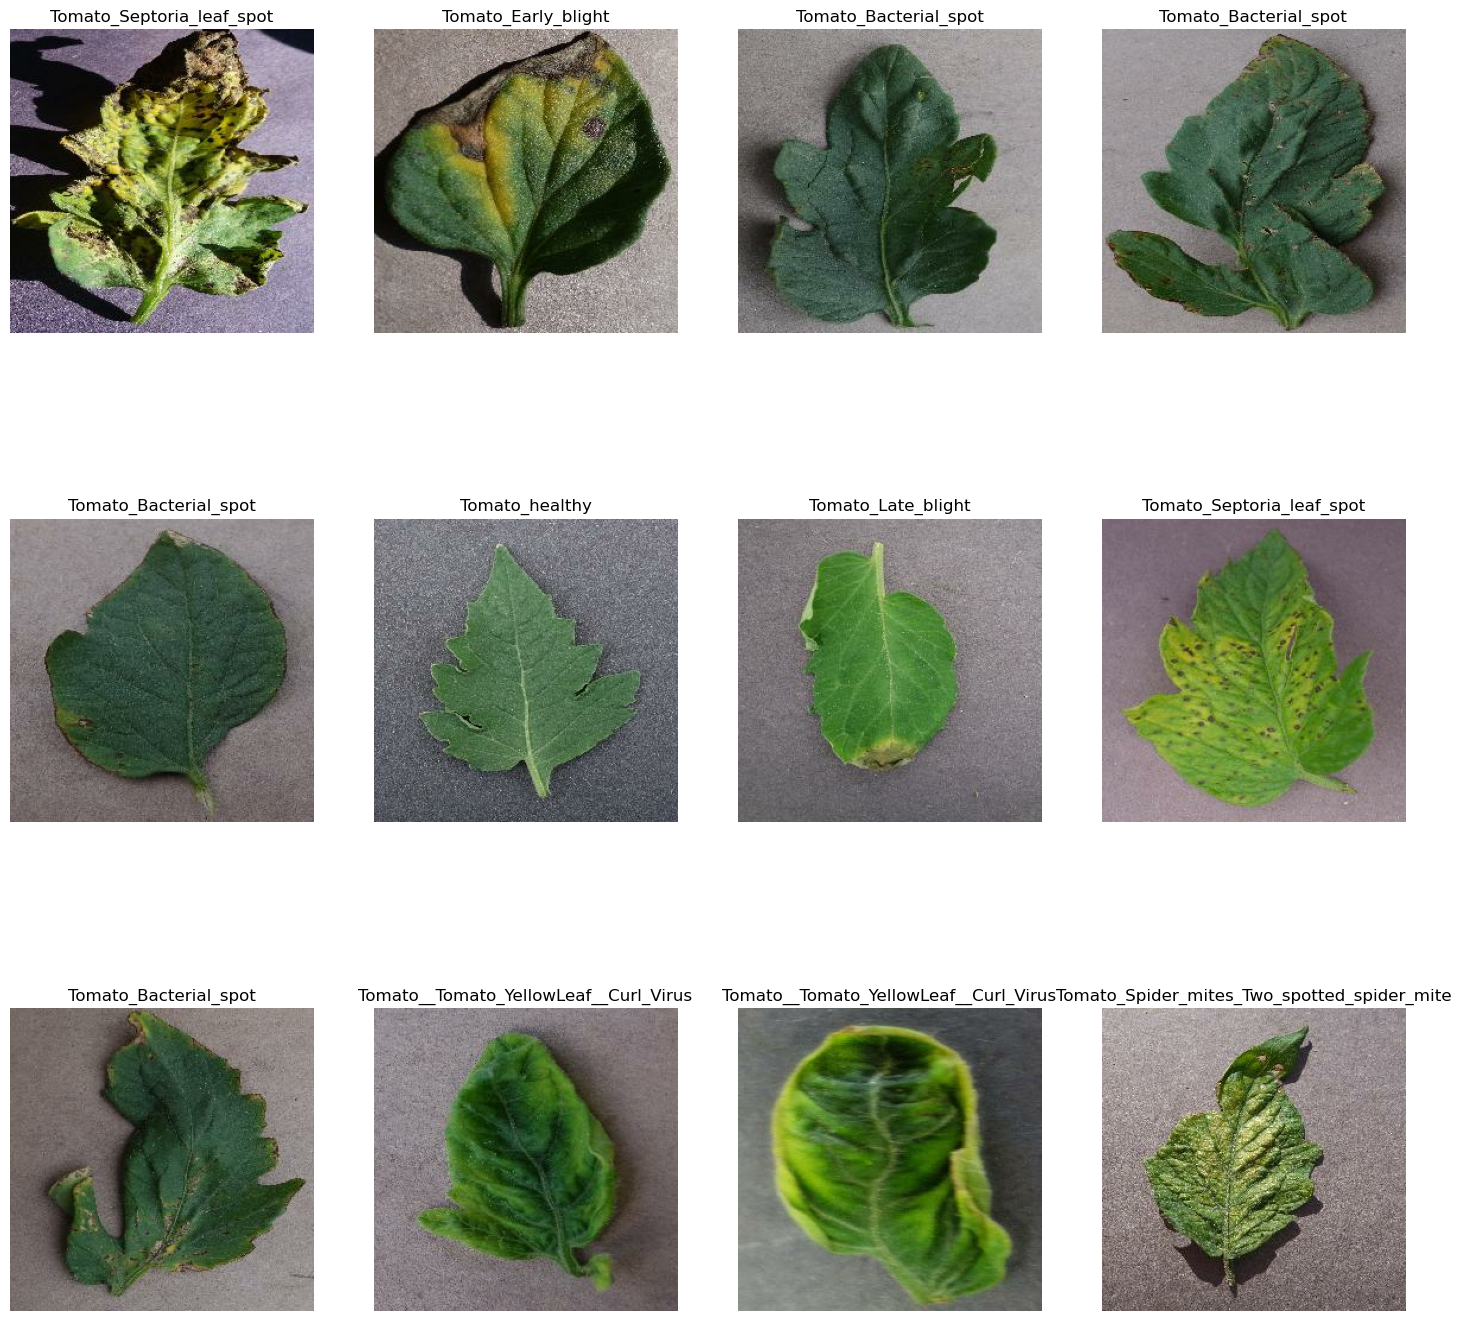

In [9]:
plt.figure(figsize=(18, 18))
for image_batch, label_batch in dataset.take(1):
    for i in range(12):  # show only 12 images
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[int(label_batch[i].numpy())])  # fix label indexing
        plt.axis("off")

In [10]:
len(dataset)

501

In [11]:
train_size = 0.8
len(dataset)*train_size

400.8

In [12]:
train_ds = dataset.take(400)
len(train_ds)

400

In [13]:
test_ds = dataset.skip(400)
len(test_ds)

101

In [14]:
val_size = 0.1
len(dataset)*val_size

50.1

In [15]:
val_ds = test_ds.take(50)
len(val_ds)

50

In [16]:
test_ds = test_ds.skip(6)
len(test_ds)

95

In [17]:
def get_dataset_partitions_tf(ds, train_split = 0.8, val_split = 0.1, test_split = 0.1, shuffle=True, shuffle_size=10000):
    ds_size = len(ds)

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed = 12)
        
    train_size = int (train_split * ds_size)
    val_size = int (val_split * ds_size)

    train_ds = ds.take(train_size)

    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).take(val_size)
    return train_ds, val_ds, test_ds

In [18]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [19]:
len(train_ds)

400

In [20]:
len(val_ds)

50

In [21]:
len(test_ds)

50

In [22]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)

In [23]:
from tensorflow.keras import layers
resize_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1.0/255)
])

In [24]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),  # flip both ways
    layers.RandomRotation(0.2),                    # rotate up to 20%
    layers.RandomZoom(0.2),                        # zoom in/out by 20%
    layers.RandomContrast(0.2),                    # adjust contrast ±20%
    layers.RandomTranslation(0.1, 0.1)              # shift width/height by 10%
])

In [25]:
from tensorflow.keras import layers, models

n_classes = 10
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)  # include 3 channels (RGB)

# --- Model architecture ---
model = models.Sequential([
    resize_rescale,
    data_augmentation,
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),    
])

model.build(input_shape=input_shape)

C:\Users\KIIT\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (32, 28, 28, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (32, 12, 12, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (32, 6, 6, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (32, 2304)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 64)               │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 10)               │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 278,346 (1.06 MB)

 Trainable params: 278,346 (1.06 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# --- Compile the model ---
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [28]:

# --- Train the model ---
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    verbose=1,
    validation_data=val_ds
)

Epoch 1/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 703s 2s/step - accuracy: 0.2843 - loss: 1.9750 - val_accuracy: 0.3663 - val_loss: 2.3500
Epoch 2/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 553s 1s/step - accuracy: 0.5174 - loss: 1.3580 - val_accuracy: 0.5719 - val_loss: 1.9144
Epoch 3/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 417s 1s/step - accuracy: 0.6914 - loss: 0.8774 - val_accuracy: 0.5356 - val_loss: 2.0669
Epoch 4/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 371s 929ms/step - accuracy: 0.7718 - loss: 0.6520 - val_accuracy: 0.6162 - val_loss: 1.5850
Epoch 5/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 365s 913ms/step - accuracy: 0.8138 - loss: 0.5427 - val_accuracy: 0.5938 - val_loss: 1.9899
Epoch 6/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 351s 878ms/step - accuracy: 0.8314 - loss: 0.4763 - val_accuracy: 0.5769 - val_loss: 1.7458
Epoch 7/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 348s 869ms/step - accuracy: 0.8437 - loss: 0.4330 - val_accuracy: 0.8100 - val_loss: 0.6562
Epoch 8/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 346s 866ms/step - accuracy: 0.8675 - loss: 0.

In [30]:
scores = model.evaluate(test_ds)

50/50 ━━━━━━━━━━━━━━━━━━━━ 97s 264ms/step - accuracy: 0.9081 - loss: 0.2851


In [31]:
scores

[0.2925863564014435, 0.9106249809265137]

In [32]:
history

In [33]:
history.params

{'verbose': 1, 'epochs': 50, 'steps': 400}

In [34]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [ ]:
history.history['accuracy']

[0.359375,
 0.5825781226158142,
 0.714062511920929,
 0.7767187356948853,
 0.8162500262260437,
 0.8369531035423279,
 0.8548437356948853,
 0.8737499713897705,
 0.8824218511581421,
 0.8992968797683716,
 0.9042187333106995,
 0.9067187309265137,
 0.9103124737739563,
 0.920703113079071,
 0.923046886920929,
 0.926953136920929,
 0.9334375262260437,
 0.9346874952316284,
 0.9375781416893005,
 0.9458593726158142,
 0.9410937428474426,
 0.9432031512260437,
 0.9467187523841858,
 0.9470312595367432,
 0.9555468559265137,
 0.9517968893051147,
 0.9559375047683716,
 0.9567187428474426,
 0.958203136920929,
 0.953906238079071,
 0.9577343463897705,
 0.9612500071525574,
 0.962109386920929,
 0.9625781178474426,
 0.9595312476158142,
 0.9600781202316284,
 0.9666406512260437,
 0.9623437523841858,
 0.9627344012260437,
 0.9652343988418579,
 0.9689062237739563,
 0.9692187309265137,
 0.9653124809265137,
 0.9677343964576721,
 0.9689843654632568,
 0.9721875190734863,
 0.9683593511581421,
 0.9740625023841858,
 0.970468

In [36]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

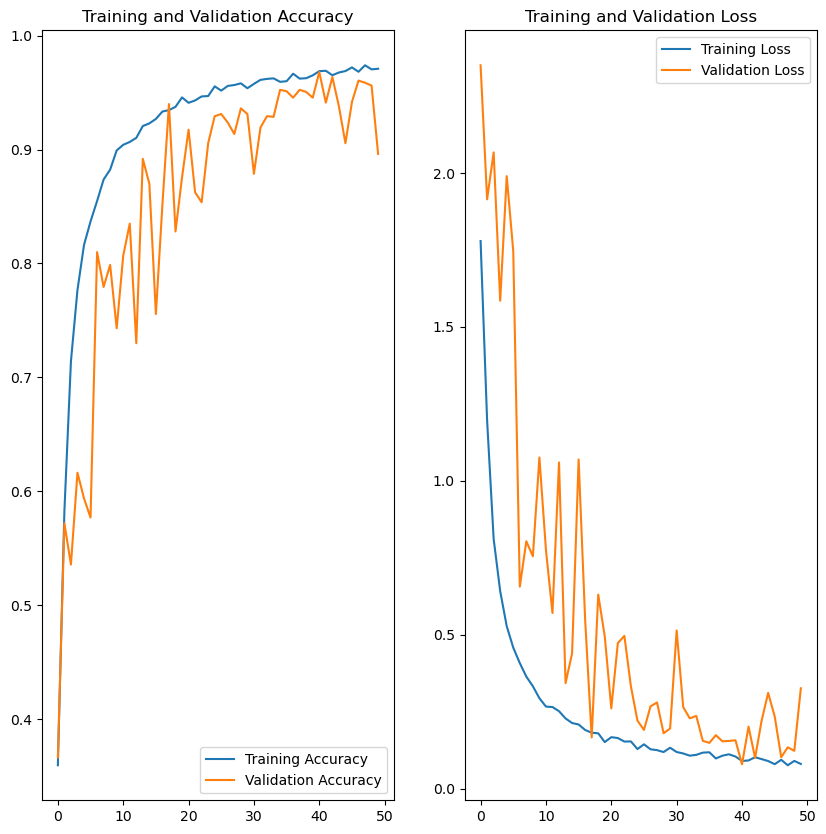

In [37]:
plt.figure(figsize=(10,10))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS), acc, label = 'Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label = 'Validation Accuracy')
plt.legend(loc = 'lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1,2,2)
plt.plot(range(EPOCHS), loss, label = 'Training Loss')
plt.plot(range(EPOCHS), val_loss, label = 'Validation Loss')
plt.legend(loc = 'upper right')
plt.title('Training and Validation Loss')
plt.show()

In [40]:
import numpy as np

np.argmax([6.7133916e-04, 1.7726888e-04, 9.9439973e-01, 3.0831576e-05,
       6.7915513e-05, 4.7578726e-07, 1.3232903e-05, 1.8418611e-03,
       5.8738969e-08, 2.7972588e-03])

2

First image to predict


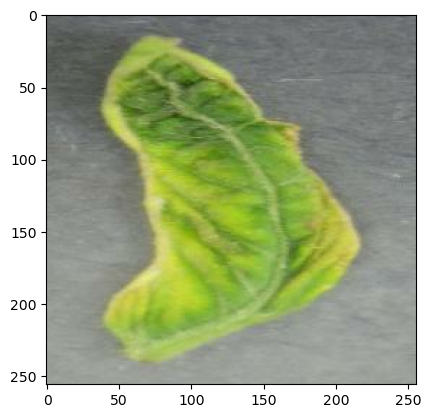

Actual label: Tomato__Tomato_YellowLeaf__Curl_Virus
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 723ms/step
[7.2655089e-02 1.2737172e-10 7.8168072e-05 3.2240575e-07 4.5609262e-08
 3.7484238e-09 9.1666327e-11 9.2726636e-01 1.3053750e-19 6.2638085e-12]
Predicted label: Tomato__Tomato_YellowLeaf__Curl_Virus


In [41]:
import numpy as np
for images_batch, labels_batch in test_ds.take(1):
    first_image = images_batch[0].numpy().astype("uint8")
    first_label = labels_batch[0].numpy()

    print("First image to predict")
    plt.imshow(first_image)
    #plt.axis("off")
    plt.show()

    print("Actual label:", class_names[first_label])
    
    batch_prediction = model.predict(images_batch)
    print(batch_prediction[0])
    print("Predicted label:", class_names[np.argmax(batch_prediction[0])])

In [42]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0) # Create a batch

    predictions = model.predict(img_array)

    predicted_class = [class_names[np.argmax(predictions[0])]]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


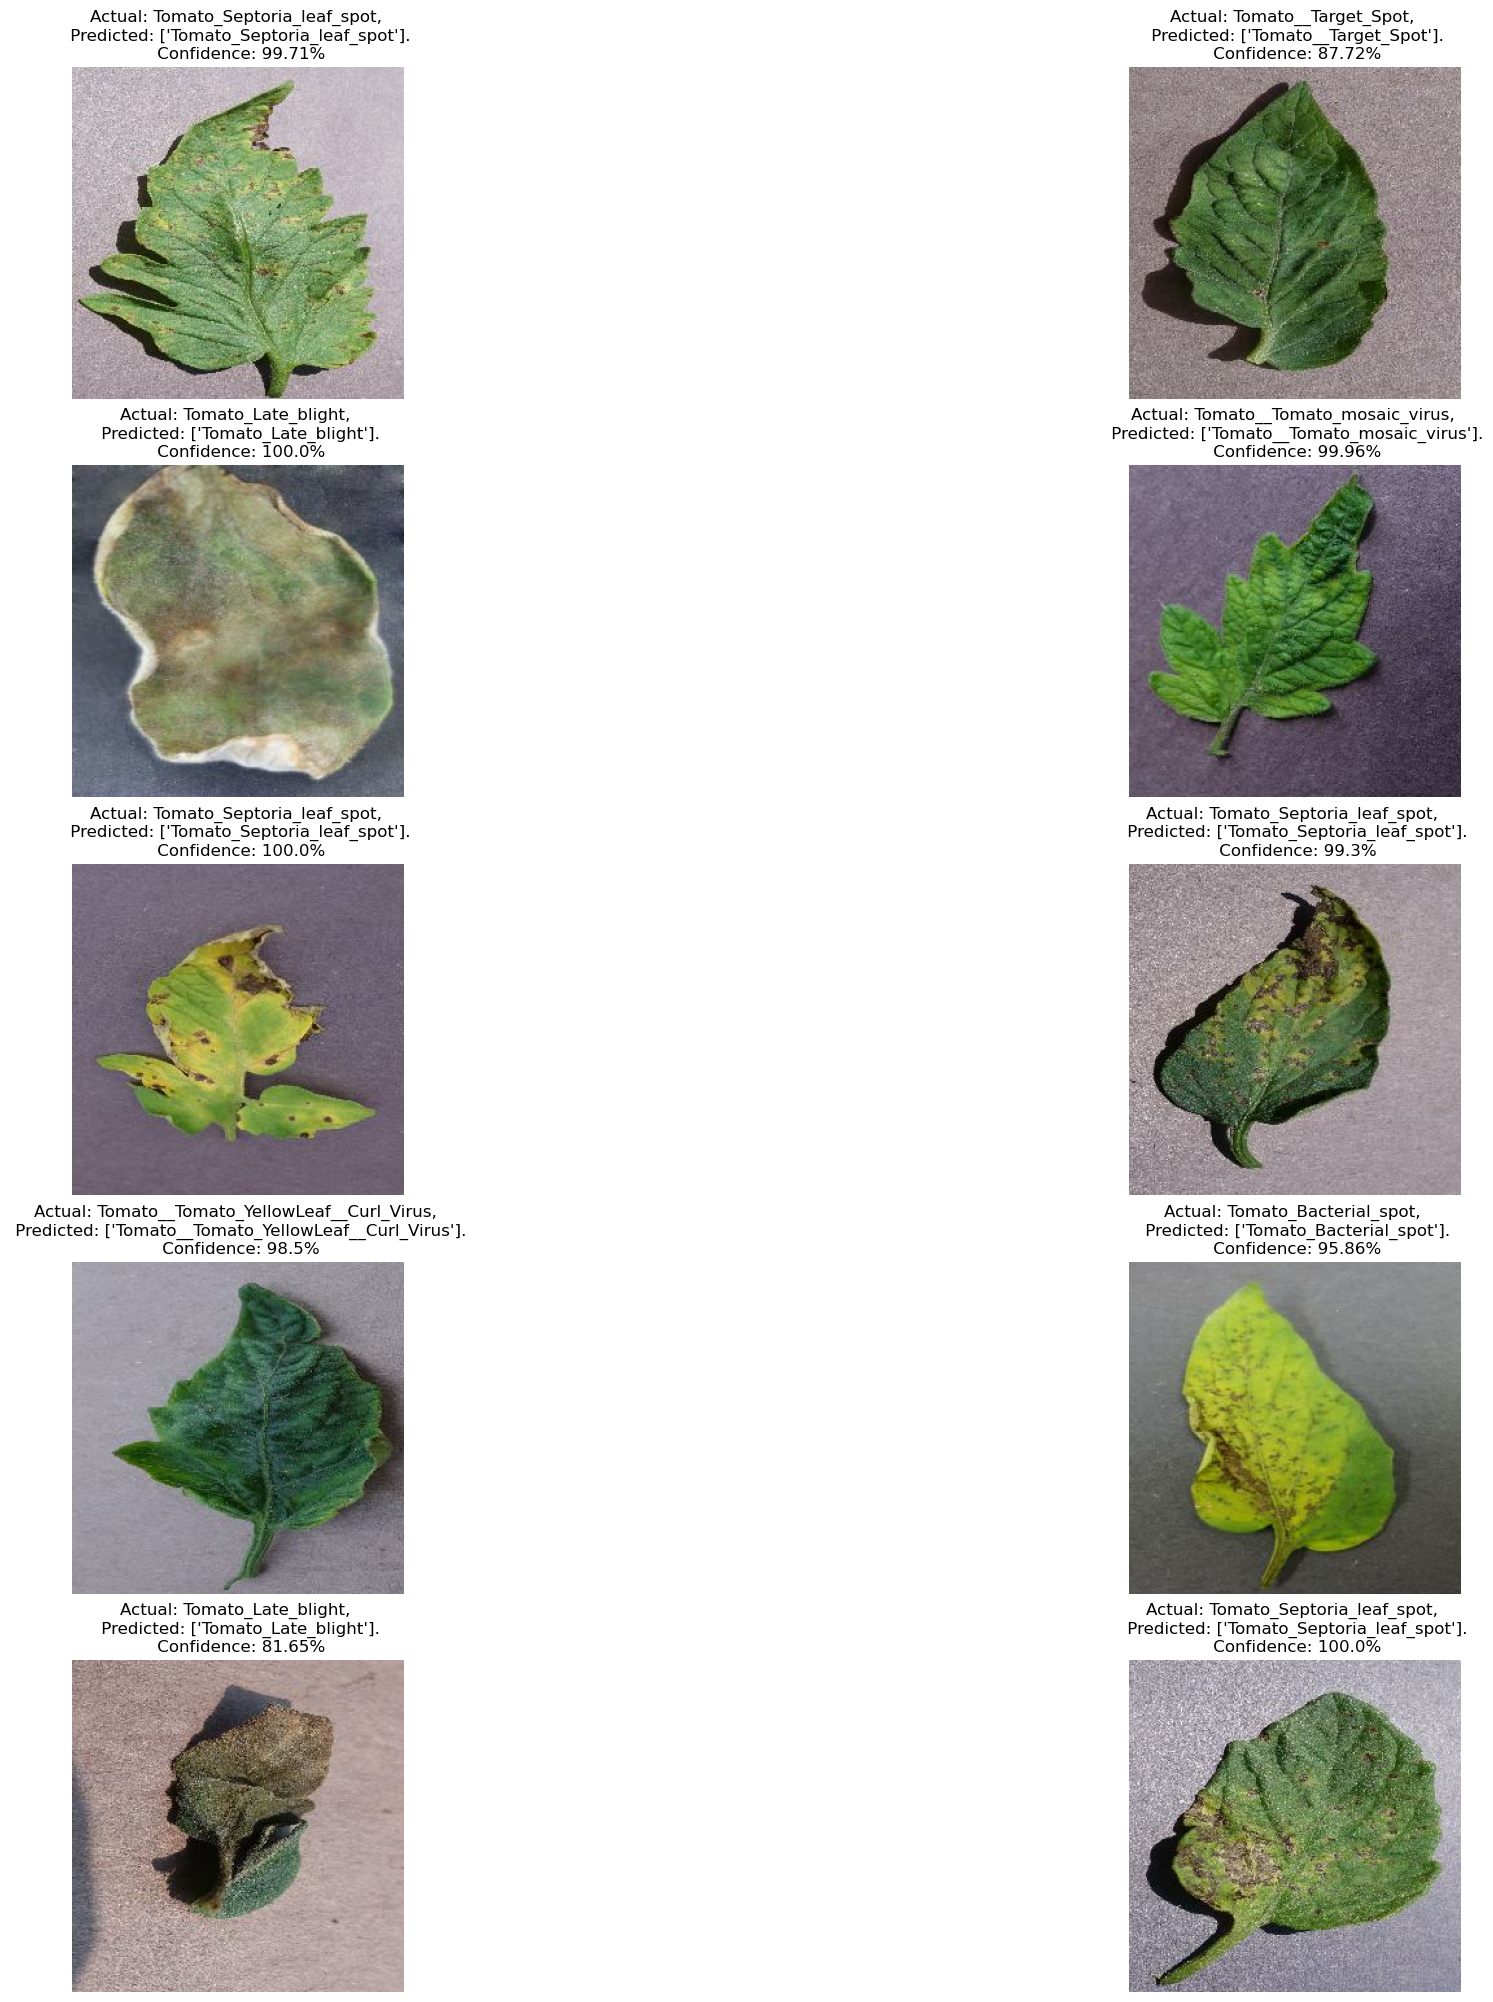

In [43]:
for images, labels in test_ds.take(1):
    plt.figure(figsize=(25,25))
    for i in range(10):
        ax = plt.subplot(5, 2, i+1)   # 5 rows, 2 cols
        plt.imshow(images[i].numpy().astype("uint8"))
        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]]

        plt.title(f"Actual: {actual_class}, \n Predicted: {predicted_class}.\n Confidence: {confidence}%")

        plt.axis("off")

In [44]:
model_version = 2
model.export(f"../Saved Models/{model_version}")

INFO:tensorflow:Assets written to: ../Saved Models/2\assets


INFO:tensorflow:Assets written to: ../Saved Models/2\assets


Saved artifact at '../Saved Models/2'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  1747491322768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1747491322000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1747494390864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1747494403728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1747494403920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1747693718992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1747693719760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1747693719568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1747693720336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1747693718608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1747693721104: TensorSpec(shape=

In [45]:
import os
model_version = max([int(i) for i in os.listdir("../Saved Models") + [0]]) + 1
model.export(f"../Saved Models/{model_version}")

INFO:tensorflow:Assets written to: ../Saved Models/5\assets


INFO:tensorflow:Assets written to: ../Saved Models/5\assets


Saved artifact at '../Saved Models/5'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  1747491322768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1747491322000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1747494390864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1747494403728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1747494403920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1747693718992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1747693719760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1747693719568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1747693720336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1747693718608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1747693721104: TensorSpec(shape=

In [46]:
import tensorflow as tf

# The path to the directory containing saved_model.pb
model_path = 'C:\\Users\\KIIT\\Desktop\\PROJECTS\\Tomato Disease\\Saved Models\\4'

# Load the model using TFSMLayer (for inference only)
loaded_model = tf.keras.layers.TFSMLayer(model_path, call_endpoint='serving_default')

# Example: run inference (input_tensor must match model input shape)
# output = loaded_model(input_tensor)

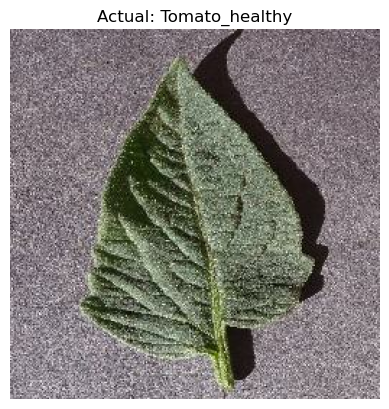

Predicted: Tomato_healthy (Confidence: 100.00%)


In [47]:
import numpy as np
import random

# Take a random batch from test_ds
for images_batch, labels_batch in test_ds.shuffle(1000).take(1):
    # Pick a random index from the batch
    idx = random.randint(0, images_batch.shape[0] - 1)
    img = images_batch[idx].numpy().astype("uint8")
    label = labels_batch[idx].numpy()

    plt.imshow(img)
    plt.title(f"Actual: {class_names[label]}")
    plt.axis("off")
    plt.show()

    # Preprocess image for prediction
    img_input = tf.expand_dims(images_batch[idx], 0)  # shape: (1, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
    pred = loaded_model(img_input)
    pred_tensor = pred['output_0']  # extract tensor from dict
    pred_label = np.argmax(pred_tensor[0])
    confidence = np.max(pred_tensor[0]) * 100

    print(f"Predicted: {class_names[pred_label]} (Confidence: {confidence:.2f}%)")

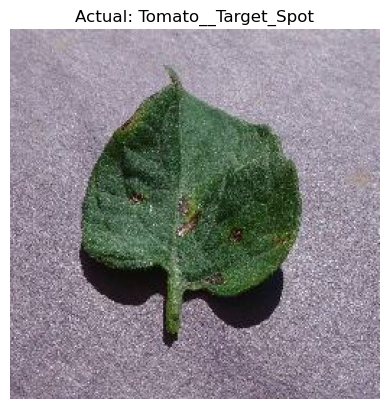

Predicted: Tomato__Target_Spot (Confidence: 100.00%)


In [48]:
import numpy as np
import random

# Take a random batch from test_ds

# Pick a random index from the batch
idx = 5
img = images_batch[idx].numpy().astype("uint8")
label = labels_batch[idx].numpy()

plt.imshow(img)
plt.title(f"Actual: {class_names[label]}")
plt.axis("off")
plt.show()

# Preprocess image for prediction
img_input = tf.expand_dims(images_batch[idx], 0)  # shape: (1, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
pred = loaded_model(img_input)
pred_tensor = pred['output_0']  # extract tensor from dict
pred_label = np.argmax(pred_tensor[0])
confidence = np.max(pred_tensor[0]) * 100

print(f"Predicted: {class_names[pred_label]} (Confidence: {confidence:.2f}%)")

Images batch shape: (32, 256, 256, 3)
Labels batch shape: (32,)
First label: 7


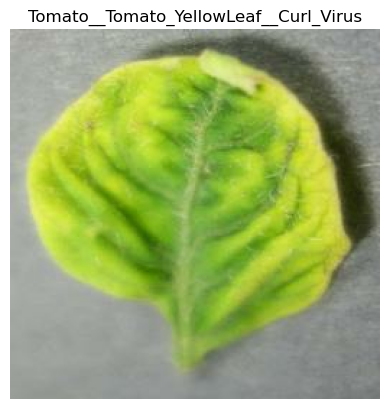

Images batch shape: (32, 256, 256, 3)
Labels batch shape: (32,)
First label: 1


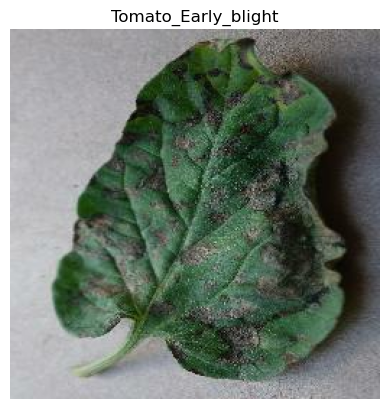

Images batch shape: (32, 256, 256, 3)
Labels batch shape: (32,)
First label: 2


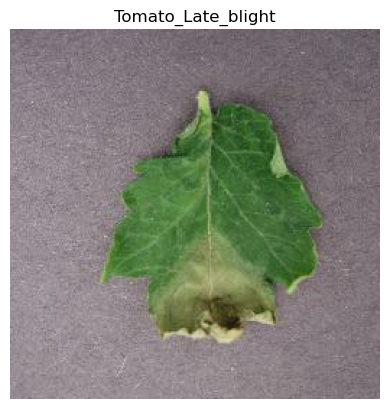

Images batch shape: (32, 256, 256, 3)
Labels batch shape: (32,)
First label: 4


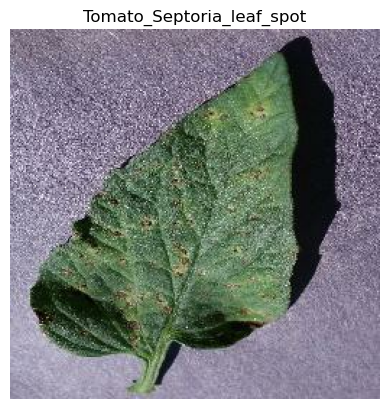

Images batch shape: (32, 256, 256, 3)
Labels batch shape: (32,)
First label: 6


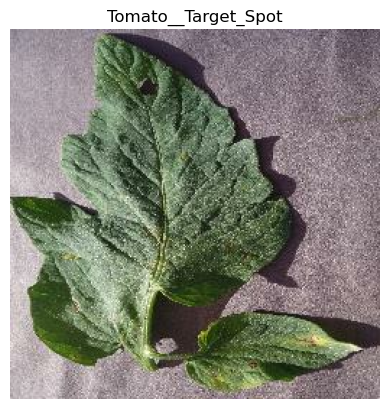

Images batch shape: (32, 256, 256, 3)
Labels batch shape: (32,)
First label: 2


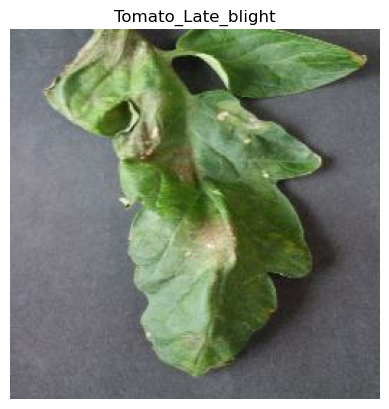

Images batch shape: (32, 256, 256, 3)
Labels batch shape: (32,)
First label: 7


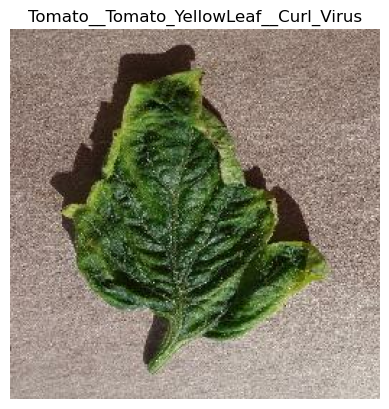

Images batch shape: (32, 256, 256, 3)
Labels batch shape: (32,)
First label: 3


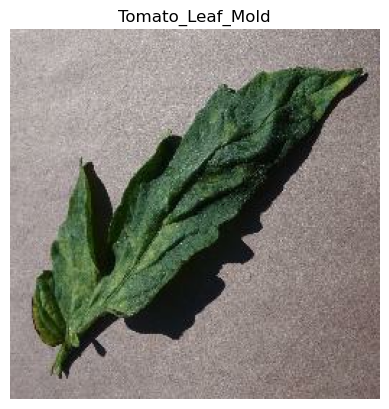

Images batch shape: (32, 256, 256, 3)
Labels batch shape: (32,)
First label: 0


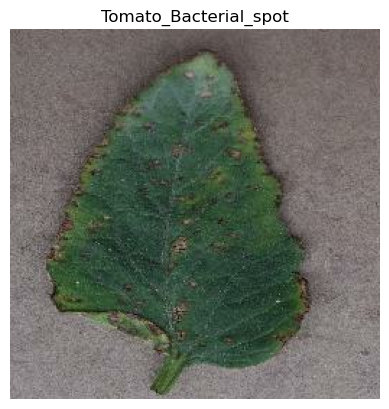

Images batch shape: (32, 256, 256, 3)
Labels batch shape: (32,)
First label: 2


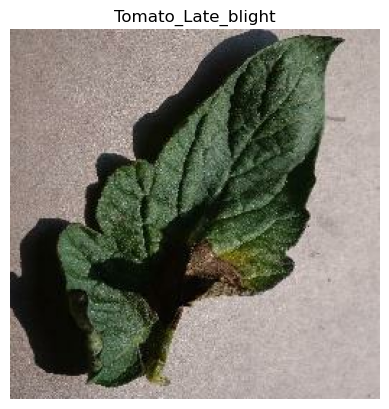

In [49]:
# To inspect a few samples from the tf.data.Dataset, use .take() and iterate
for images, labels in dataset.take(10):
	print("Images batch shape:", images.shape)
	print("Labels batch shape:", labels.shape)
	print("First label:", labels[0].numpy())
	plt.imshow(images[0].numpy().astype("uint8"))
	plt.title(class_names[labels[0]])
	plt.axis("off")
	plt.show()